In [5]:
# from google.colab import files
# uploaded = files.upload()

In [6]:
import pandas as pd

df = pd.read_csv("../Desktop/DataScience-py_clg/Labs/Lab-07/VISA_Details_2010-2013-oct.csv")

df.head()

,COUNTRY,MISSION,VISA ISSUE DATE,EMPLOYMENT VISA,TOURIST VISA,BUSINESS VISA,CONFERENCE VISA,BUS VISA INDSPOUSE,BUSINESS VISA TRANSFER,DIPLOMATIC VISA,...,MEDICAL ATTENDENT VISA,MISSIONARY VISA,PILGRIMAGE VISA,RESEARCH VISA,PROJECT VISA,TRANSIT VISA,VISIT VISA,ART SURROGACY,LONG TERM VISA TRANSFER,STUDENT VISA
0,CANADA,CANADA-TORONTO,26-07-10,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,BANGLADESH,BANGLADESH-CHITTAGONG,28-07-10,0,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,BANGLADESH,BANGLADESH-CHITTAGONG,29-07-10,0,4,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,BANGLADESH,BANGLADESH-CHITTAGONG,04-08-10,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,BANGLADESH,BANGLADESH-CHITTAGONG,05-08-10,0,41,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0


In [7]:
df['VISA ISSUE DATE'] = pd.to_datetime(df['VISA ISSUE DATE'])

df['YEAR'] = df['VISA ISSUE DATE'].dt.year

visa_columns = df.columns[3:]

df['TOTAL'] = df[visa_columns].sum(axis=1)

df.head()

/tmp/ipykernel_16106/654801926.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['VISA ISSUE DATE'] = pd.to_datetime(df['VISA ISSUE DATE'])


,COUNTRY,MISSION,VISA ISSUE DATE,EMPLOYMENT VISA,TOURIST VISA,BUSINESS VISA,CONFERENCE VISA,BUS VISA INDSPOUSE,BUSINESS VISA TRANSFER,DIPLOMATIC VISA,...,PILGRIMAGE VISA,RESEARCH VISA,PROJECT VISA,TRANSIT VISA,VISIT VISA,ART SURROGACY,LONG TERM VISA TRANSFER,STUDENT VISA,YEAR,TOTAL
0,CANADA,CANADA-TORONTO,2010-07-26,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,2010,2011
1,BANGLADESH,BANGLADESH-CHITTAGONG,2010-07-28,0,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2010,2017
2,BANGLADESH,BANGLADESH-CHITTAGONG,2010-07-29,0,4,1,1,0,0,0,...,0,0,0,0,0,0,0,0,2010,2016
3,BANGLADESH,BANGLADESH-CHITTAGONG,2010-04-08,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2010,2011
4,BANGLADESH,BANGLADESH-CHITTAGONG,2010-05-08,0,41,0,0,0,0,0,...,0,0,0,0,0,2,0,0,2010,2053


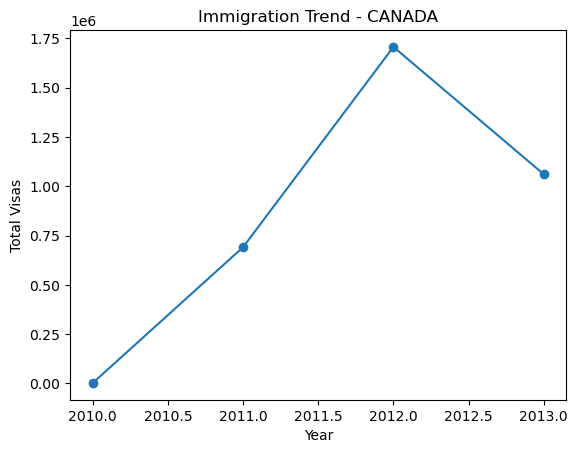

In [8]:
import matplotlib.pyplot as plt

country = "CANADA"

country_data = df[df['COUNTRY'] == country]

yearly = country_data.groupby('YEAR')['TOTAL'].sum()

plt.figure()
yearly.plot(marker='o')
plt.title(f"Immigration Trend - {country}")
plt.xlabel("Year")
plt.ylabel("Total Visas")
plt.show()

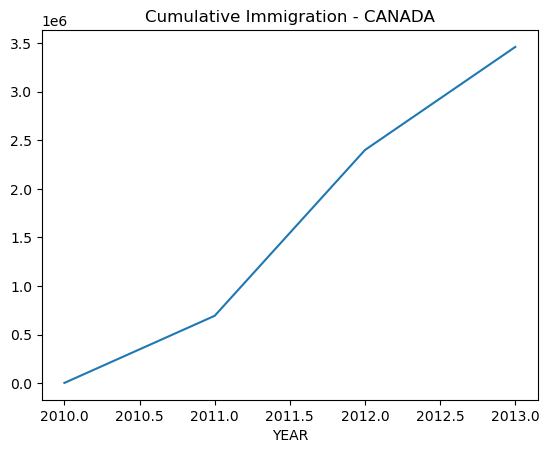

In [9]:
cumulative = yearly.cumsum()

plt.figure()
cumulative.plot()
plt.title(f"Cumulative Immigration - {country}")
plt.show()

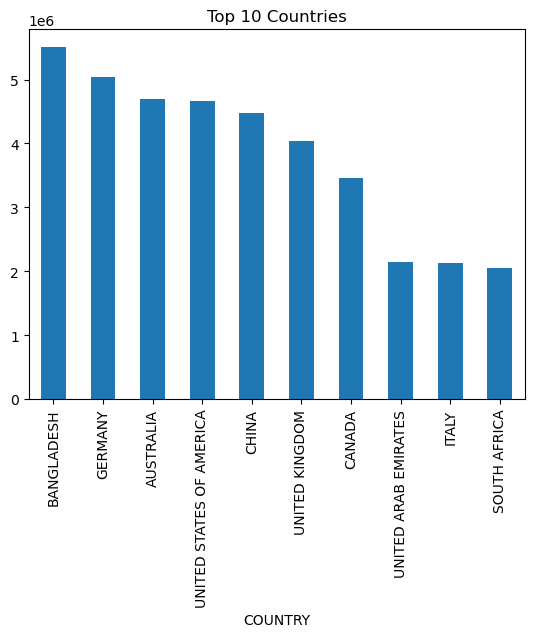

In [10]:
country_totals = df.groupby('COUNTRY')['TOTAL'].sum().sort_values(ascending=False)

plt.figure()
country_totals.head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

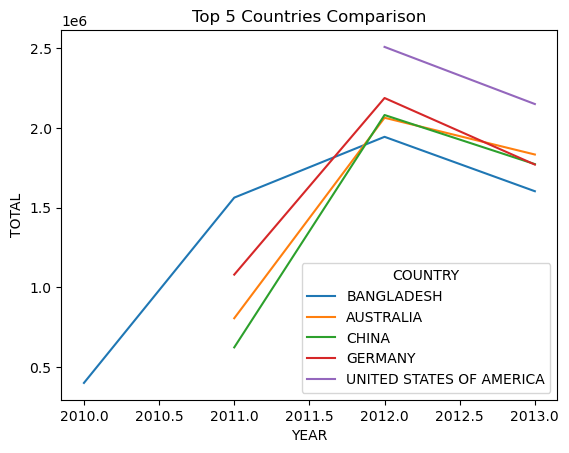

In [11]:
import seaborn as sns

top5 = country_totals.head(5).index

df_top5 = df[df['COUNTRY'].isin(top5)]

grouped = df_top5.groupby(['YEAR','COUNTRY'])['TOTAL'].sum().reset_index()

sns.lineplot(data=grouped, x='YEAR', y='TOTAL', hue='COUNTRY')
plt.title("Top 5 Countries Comparison")
plt.show()

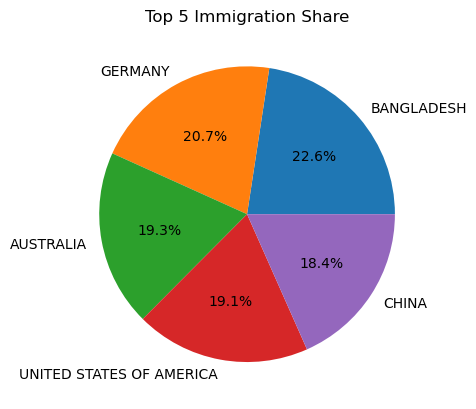

In [12]:
top5_values = country_totals.head(5)

plt.figure()
plt.pie(top5_values, labels=top5_values.index, autopct='%1.1f%%')
plt.title("Top 5 Immigration Share")
plt.show()

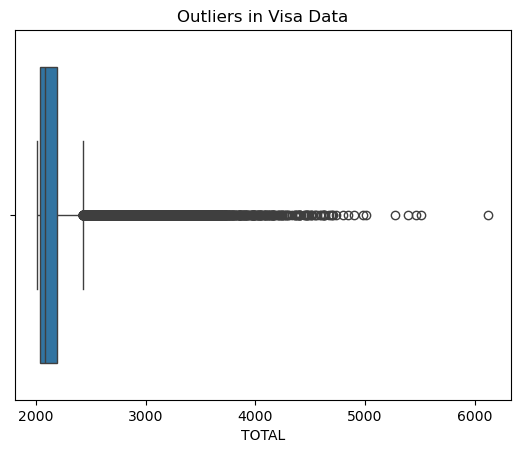

In [13]:
plt.figure()
sns.boxplot(x=df['TOTAL'])
plt.title("Outliers in Visa Data")
plt.show()

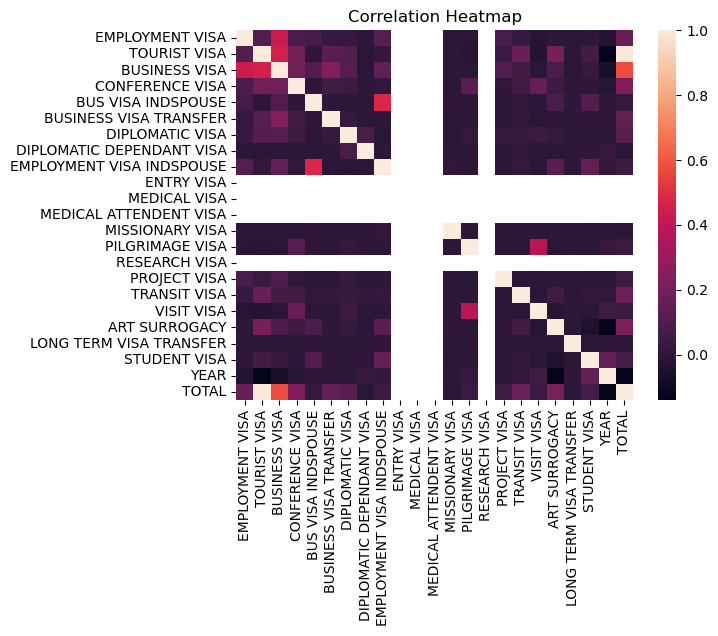

In [14]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure()
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

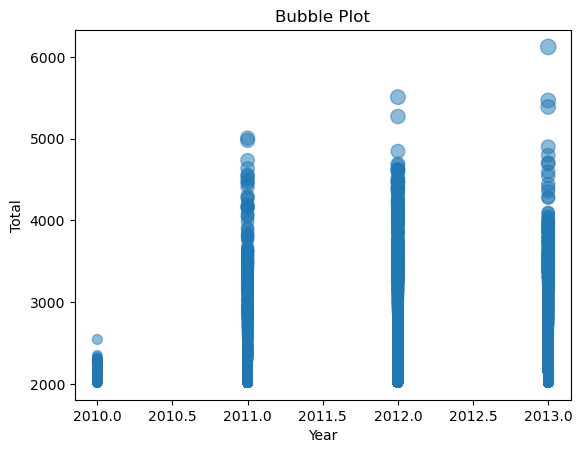

In [15]:
plt.figure()
plt.scatter(df['YEAR'], df['TOTAL'], s=df['TOTAL']/50, alpha=0.5)
plt.title("Bubble Plot")
plt.xlabel("Year")
plt.ylabel("Total")
plt.show()

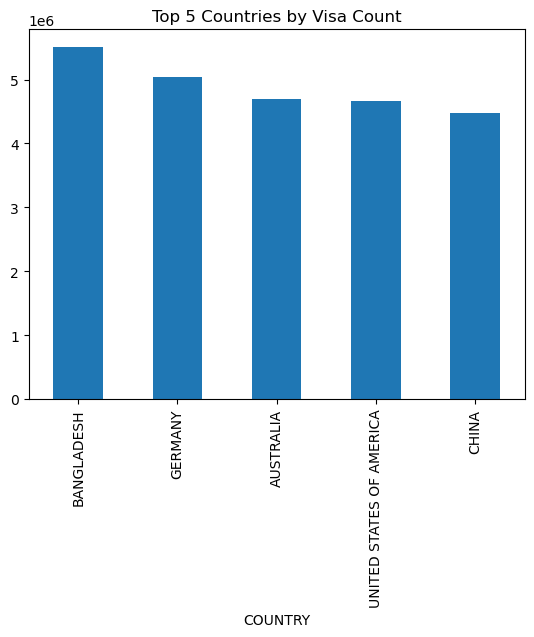

In [16]:
top5_values.plot(kind='bar')
plt.title("Top 5 Countries by Visa Count")
plt.show()

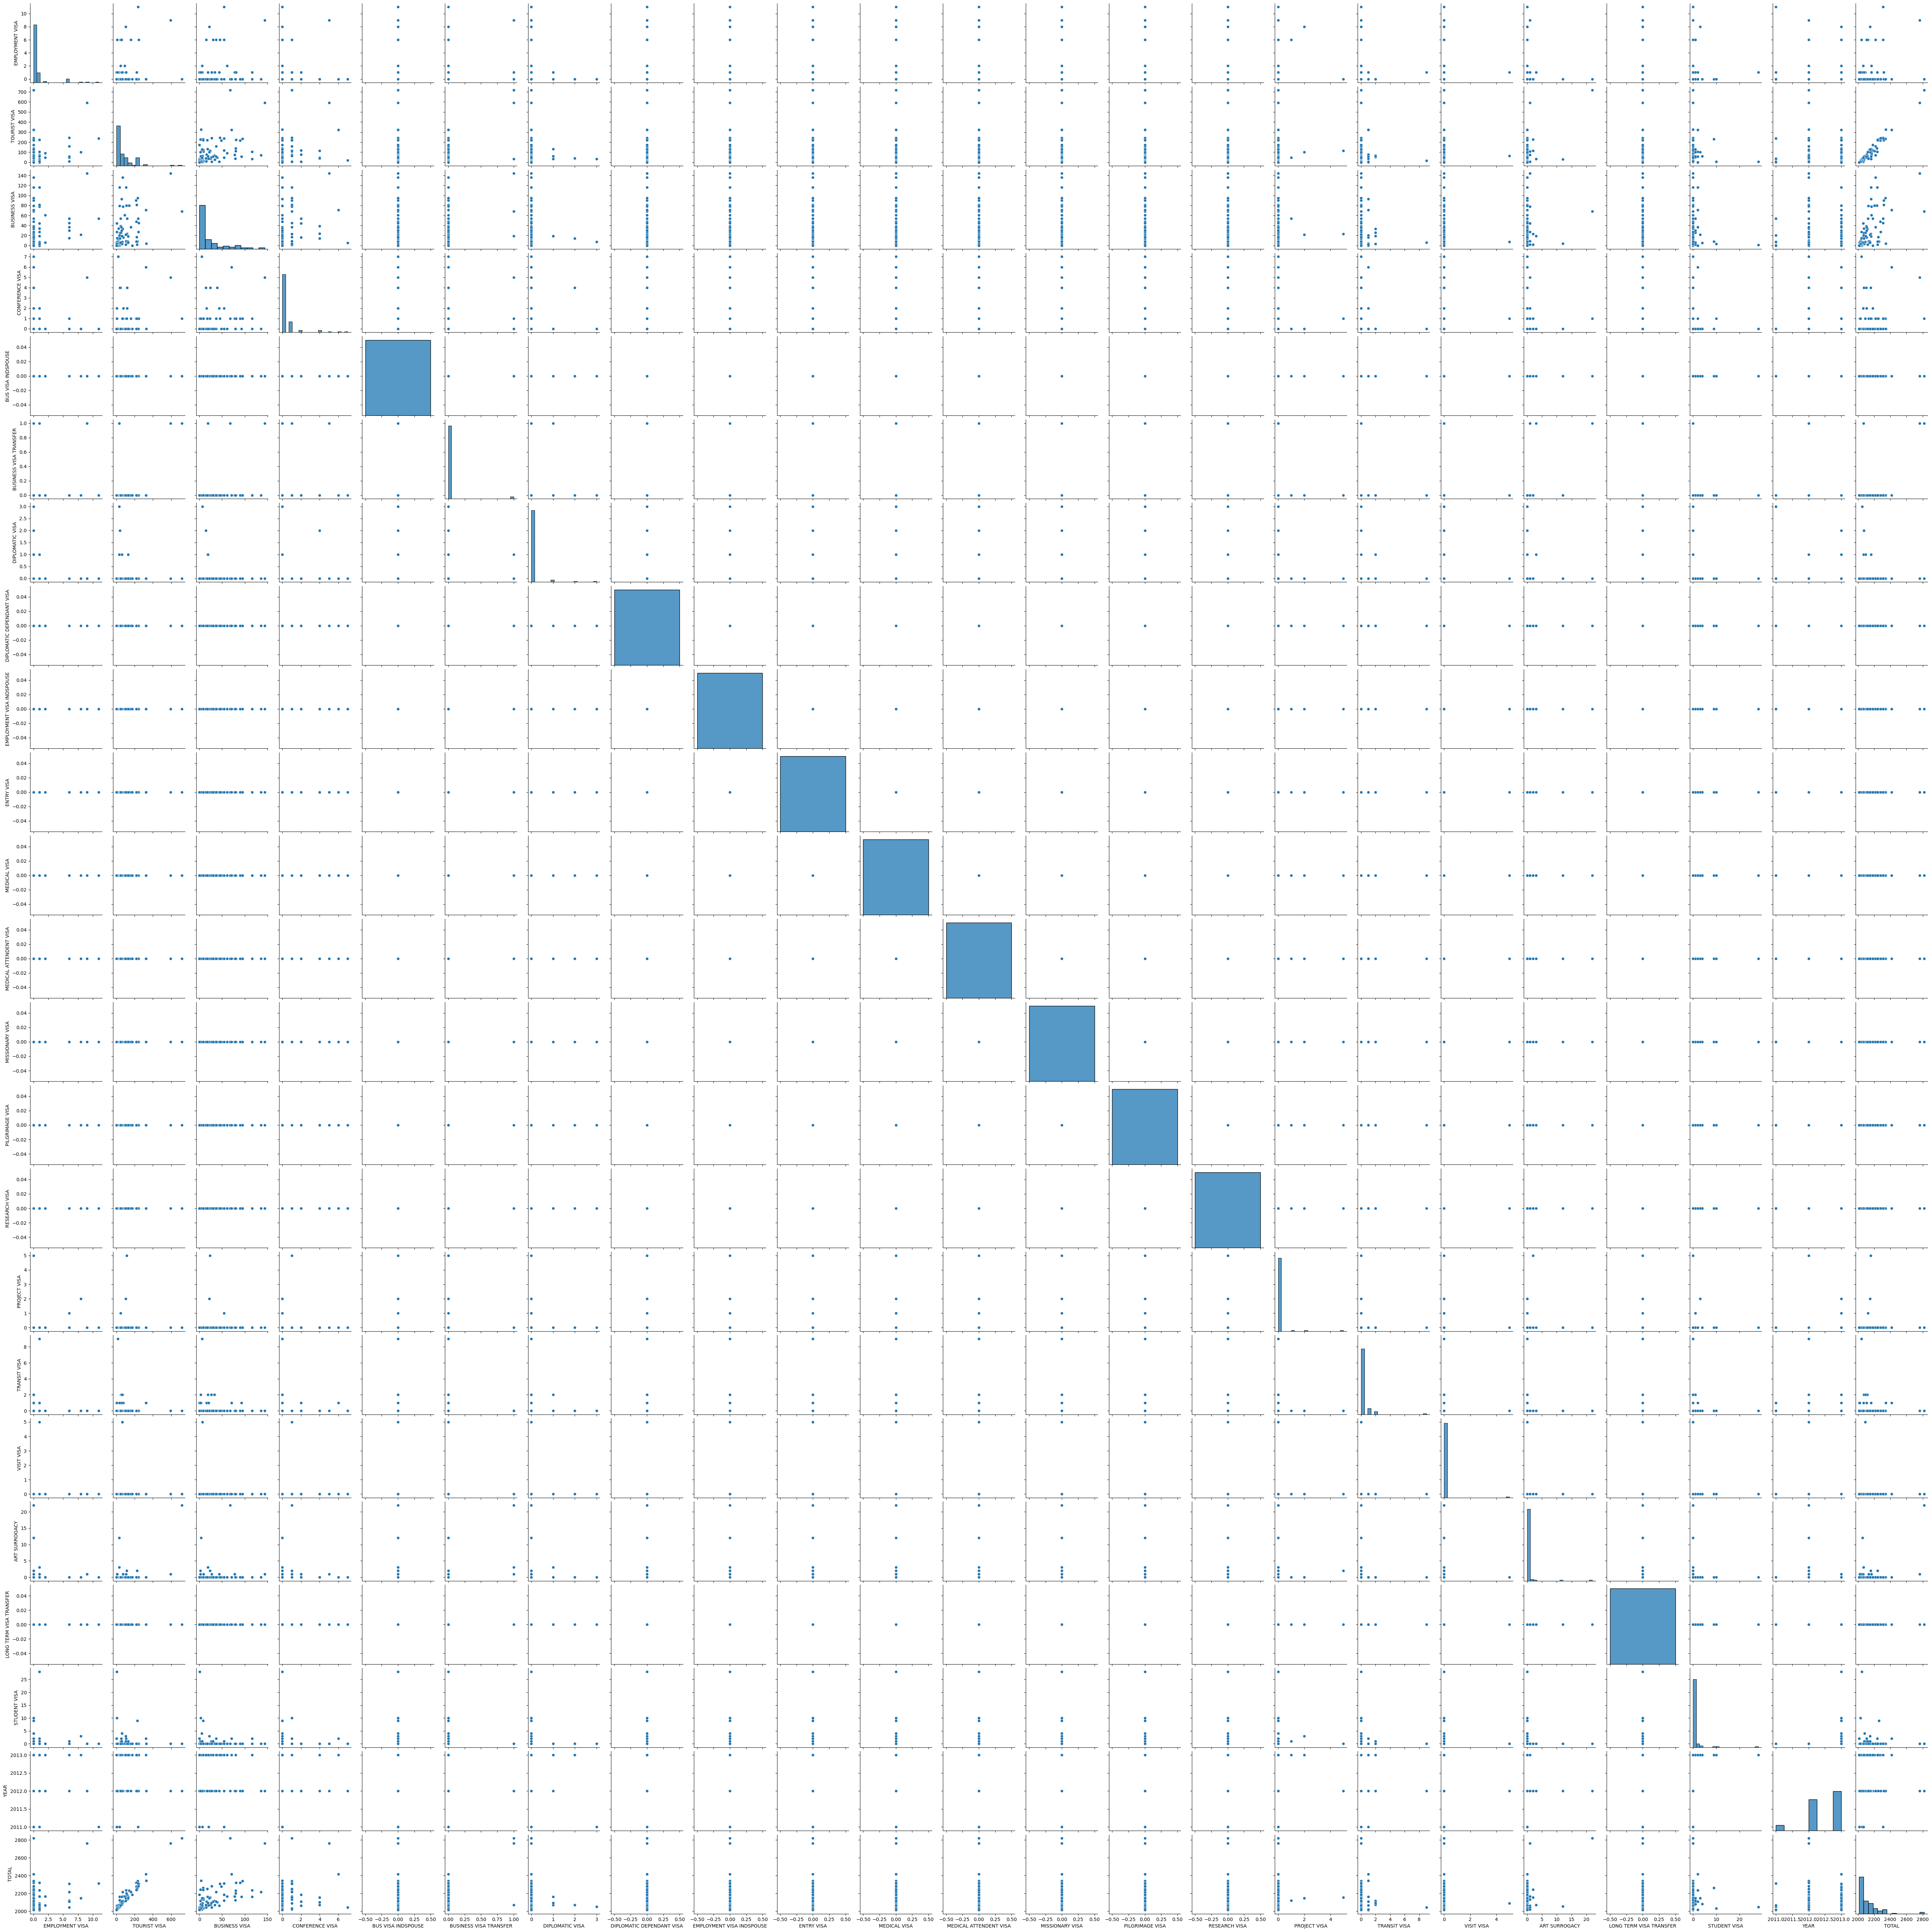

In [17]:
sns.pairplot(numeric_df.sample(100))  # sample to avoid lag
plt.show()